In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [5]:
df1 = pd.read_csv("C:/Users/SHAH KAVYA RONAK/OneDrive/ドキュメント/vadodara house price.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,Ready To Move,Alkapuri,3 BHK,Alkapuri Heights,1650,3,2,110.0
1,Built-up Area,Ready To Move,Akota,2 Bedroom,Akota Residency,1250,2,1,68.0
2,Super built-up Area,Under Construction,Gotri,3 BHK,Gotri Greens,1750 Sq. Foot,3,2,82.0
3,Built-up Area,Ready To Move,Manjalpur,2 BHK,Manjalpur Palace,1180,2,2,55.0
4,Super built-up Area,Ready To Move,Vasna Road,4 BHK,Vasna Elite,2400,4,3,160.0


In [6]:
df1.shape

(17, 9)

In [7]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up Area           3
Carpet Area             3
Super built-up Area    10
plot-area               1
Name: area_type, dtype: int64

In [8]:
df2 = df1.drop(['area_type','society','balcony','availability'],axis='columns')
df2.head()

,location,size,total_sqft,bath,price
0,Alkapuri,3 BHK,1650,3,110.0
1,Akota,2 Bedroom,1250,2,68.0
2,Gotri,3 BHK,1750 Sq. Foot,3,82.0
3,Manjalpur,2 BHK,1180,2,55.0
4,Vasna Road,4 BHK,2400,4,160.0


In [9]:
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         2
dtype: int64

In [10]:
df3 = df2.dropna()
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [11]:
df3.shape

(15, 5)

In [12]:
df3['size'].unique()

array(['3 BHK', '2 Bedroom', '2 BHK', '4 BHK'], dtype=object)

In [13]:
df3['bhk']=df3['size'].apply(lambda x: int(x.split(' ')[0]))

C:\Users\SHAH KAVYA RONAK\AppData\Local\Temp\ipykernel_16296\2989175054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk']=df3['size'].apply(lambda x: int(x.split(' ')[0]))


In [14]:
df3.head()

,location,size,total_sqft,bath,price,bhk
0,Alkapuri,3 BHK,1650,3,110.0,3
1,Akota,2 Bedroom,1250,2,68.0,2
2,Gotri,3 BHK,1750 Sq. Foot,3,82.0,3
3,Manjalpur,2 BHK,1180,2,55.0,2
4,Vasna Road,4 BHK,2400,4,160.0,4


In [15]:
df3['bhk'].unique()

array([3, 2, 4])

In [16]:
df3[df3.bhk>2]

,location,size,total_sqft,bath,price,bhk
0,Alkapuri,3 BHK,1650,3,110.0,3
2,Gotri,3 BHK,1750 Sq. Foot,3,82.0,3
4,Vasna Road,4 BHK,2400,4,160.0,4
7,Bhayli,3 BHK,1700,3,88.0,3
9,New VIP Road,3 BHK,1600,3,80.0,3
11,Bhayli Road,4 BHK,400,4,160.0,4
13,Vasna Road,4 BHK,2400,4,150.0,4
14,Savli,4 BHK,1400,4,120.0,4
15,Vasna Road,4 BHK,3400,4,115.0,4
16,Vasna Road,4 BHK,2300,4,190.0,4


In [17]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [18]:
df3[~df3['total_sqft'].apply(is_float)]

,location,size,total_sqft,bath,price,bhk
2,Gotri,3 BHK,1750 Sq. Foot,3,82.0,3
12,Savli,2 BHK,550-750,2,100.0,2


In [19]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [20]:
 convert_sqft_to_num('1700')

1700.0

In [21]:
 convert_sqft_to_num('550-750')

650.0

In [22]:
 convert_sqft_to_num('1750 sq.foot')

In [23]:
df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4.head()

,location,size,total_sqft,bath,price,bhk
0,Alkapuri,3 BHK,1650.0,3,110.0,3
1,Akota,2 Bedroom,1250.0,2,68.0,2
2,Gotri,3 BHK,NaN,3,82.0,3
3,Manjalpur,2 BHK,1180.0,2,55.0,2
4,Vasna Road,4 BHK,2400.0,4,160.0,4


In [24]:
df4.loc[12]

location      Savli
size          2 BHK
total_sqft    650.0
bath              2
price         100.0
bhk               2
Name: 12, dtype: object

In [25]:
(550+750)/2

650.0

In [26]:
df4.head(3)

,location,size,total_sqft,bath,price,bhk
0,Alkapuri,3 BHK,1650.0,3,110.0,3
1,Akota,2 Bedroom,1250.0,2,68.0,2
2,Gotri,3 BHK,NaN,3,82.0,3


In [27]:
df5 = df4.copy()
df5['price_per_sqft']= df5['price']*100000/df5['total_sqft']
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Alkapuri,3 BHK,1650.0,3,110.0,3,6666.666667
1,Akota,2 Bedroom,1250.0,2,68.0,2,5440.000000
2,Gotri,3 BHK,NaN,3,82.0,3,NaN
3,Manjalpur,2 BHK,1180.0,2,55.0,2,4661.016949
4,Vasna Road,4 BHK,2400.0,4,160.0,4,6666.666667


In [28]:
len(df5.location.unique())

11

In [29]:
df5.location = df5.location.apply(lambda x: x.strip())

location_stats = df5.groupby('location')['location'].agg('count')
location_stats

location
Akota           1
Alkapuri        1
Bhayli          1
Bhayli Road     1
Gotri           1
Karelibaug      1
Manjalpur       1
New VIP Road    1
Sama            1
Savli           2
Vasna Road      4
Name: location, dtype: int64

In [30]:
len(location_stats[location_stats<=2])

10

In [31]:
location_stats_less_than_2 = location_stats[location_stats<=2]
location_stats_less_than_2

location
Akota           1
Alkapuri        1
Bhayli          1
Bhayli Road     1
Gotri           1
Karelibaug      1
Manjalpur       1
New VIP Road    1
Sama            1
Savli           2
Name: location, dtype: int64

In [32]:
df5.location = df5.location.apply(lambda x:'other' if x in location_stats_less_than_2 else x)
len(df5.location.unique())

2

In [33]:
df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,other,3 BHK,1650.0,3,110.0,3,6666.666667
1,other,2 Bedroom,1250.0,2,68.0,2,5440.000000
2,other,3 BHK,NaN,3,82.0,3,NaN
3,other,2 BHK,1180.0,2,55.0,2,4661.016949
4,Vasna Road,4 BHK,2400.0,4,160.0,4,6666.666667


In [34]:
df5[df5.total_sqft/df5.bhk<500].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
11,other,4 BHK,400.0,4,160.0,4,40000.000000
12,other,2 BHK,650.0,2,100.0,2,15384.615385
14,other,4 BHK,1400.0,4,120.0,4,8571.428571


In [35]:
df5.shape

(15, 7)

In [36]:
df6=df5[~(df5.total_sqft/df5.bhk<500)]
df6.shape

(12, 7)

In [37]:
df6.price_per_sqft.describe()

count      11.000000
mean     5536.180252
std      1331.573079
min      3382.352941
25%      4696.969697
50%      5176.470588
75%      6458.333333
max      8260.869565
Name: price_per_sqft, dtype: float64

In [38]:
def remove_pps_outliers(df):
    df_out=pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        reduced_df=subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out=pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out

df7=remove_pps_outliers(df6)
df7.shape

(8, 7)

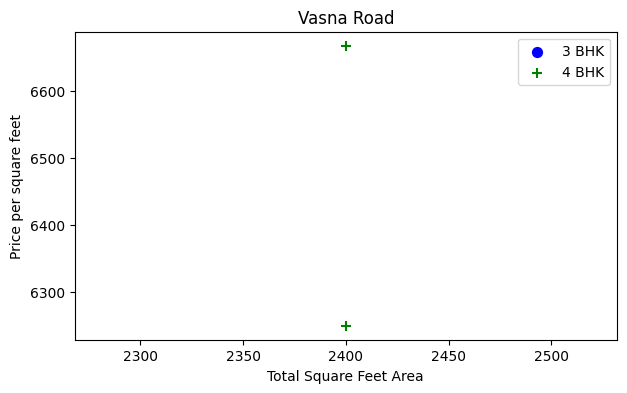

In [39]:
def plot_scatter_chart(df,location):
    bhk3=df[(df.location==location) & (df.bhk==3)]
    bhk4=df[(df.location==location) & (df.bhk==4)]
    matplotlib.rcParams['figure.figsize']=(7,4)
    plt.scatter(bhk3.total_sqft,bhk3.price_per_sqft,color='blue',label='3 BHK', s=50)
    plt.scatter(bhk4.total_sqft,bhk4.price_per_sqft,marker='+',color='green',label='4 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price per square feet")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df7,"Vasna Road")

In [40]:
def remove_bhk_outliers(df):
    exclude_indices=np.array([])
    for location,location_df in df.groupby('location'):
        bhk_stats={}
        for bhk,bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
                'mean':np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]
            }
        for bhk,bhk_df in location_df.groupby('bhk'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>2:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')

df8=remove_bhk_outliers(df7)
df8.shape

(8, 7)

Text(0, 0.5, 'Count')

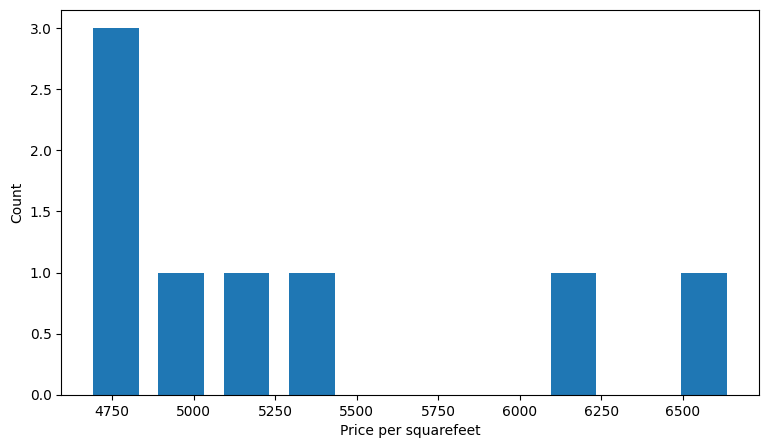

In [41]:
import matplotlib as mlt
mlt.rcParams["figure.figsize"]=(9,5)
plt.hist(df8.price_per_sqft,rwidth=0.7)
plt.xlabel("Price per squarefeet")
plt.ylabel("Count")

In [42]:
df8.bath.unique()

array([4, 2, 3])

In [43]:
df8[df8.bath>2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Vasna Road,4 BHK,2400.0,4,160.0,4,6666.666667
1,Vasna Road,4 BHK,2400.0,4,150.0,4,6250.000000
5,other,3 BHK,1700.0,3,88.0,3,5176.470588
7,other,3 BHK,1600.0,3,80.0,3,5000.000000


Text(0, 0.5, 'Count')

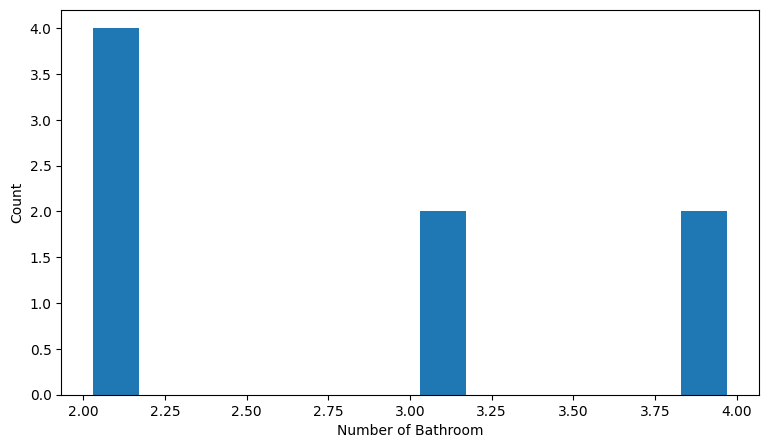

In [44]:
plt.hist(df8.bath,rwidth=0.7)
plt.xlabel("Number of Bathroom")
plt.ylabel("Count")

In [45]:
df8[df8.bath<df8.bhk+4]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Vasna Road,4 BHK,2400.0,4,160.0,4,6666.666667
1,Vasna Road,4 BHK,2400.0,4,150.0,4,6250.000000
2,other,2 Bedroom,1250.0,2,68.0,2,5440.000000
3,other,2 BHK,1180.0,2,55.0,2,4661.016949
4,other,2 BHK,1100.0,2,52.0,2,4727.272727
5,other,3 BHK,1700.0,3,88.0,3,5176.470588
6,other,2 BHK,1050.0,2,49.0,2,4666.666667
7,other,3 BHK,1600.0,3,80.0,3,5000.000000


In [46]:
df9=df8[df8.bath<df8.bhk+4]
df9.shape

(8, 7)

In [47]:
df10=df9.drop(['size','price_per_sqft'],axis='columns')
df10.head(4)

,location,total_sqft,bath,price,bhk
0,Vasna Road,2400.0,4,160.0,4
1,Vasna Road,2400.0,4,150.0,4
2,other,1250.0,2,68.0,2
3,other,1180.0,2,55.0,2


In [50]:
dummies=pd.get_dummies(df10.location)
dummies.head(3)

,Vasna Road,other
0,True,False
1,True,False
2,False,True


In [51]:
df11=pd.concat([df10,dummies.drop('other',axis='columns')],axis='columns')
df11.head(3)

,location,total_sqft,bath,price,bhk,Vasna Road
0,Vasna Road,2400.0,4,160.0,4,True
1,Vasna Road,2400.0,4,150.0,4,True
2,other,1250.0,2,68.0,2,False


In [52]:
df11.shape

(8, 6)

In [53]:
df12=df11.drop('location',axis='columns')
df12.head(2)

,total_sqft,bath,price,bhk,Vasna Road
0,2400.0,4,160.0,4,True
1,2400.0,4,150.0,4,True


In [54]:
df12.shape

(8, 5)

In [56]:
x=df12.drop('price',axis='columns')
x.head()

,total_sqft,bath,bhk,Vasna Road
0,2400.0,4,4,True
1,2400.0,4,4,True
2,1250.0,2,2,False
3,1180.0,2,2,False
4,1100.0,2,2,False


In [57]:
y=df12.price
y.head()

0    160.0
1    150.0
2     68.0
3     55.0
4     52.0
Name: price, dtype: float64

In [58]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [59]:
from sklearn.linear_model import LinearRegression
lr_clf=LinearRegression()
lr_clf.fit(x_train,y_train)
lr_clf.score(x_test,y_test)

0.647924260355031

In [60]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(),x,y,cv=cv)

array([0.67826004, 0.97863436, 0.47424013, 0.47424013, 0.99879541])

In [72]:
from sklearn.model_selection import GridSearchCV,ShuffleSplit

from sklearn.linear_model import LinearRegression,Lasso
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(x,y):
    algos = {
        'Linear_Regression':{
            'model': LinearRegression(),
            'params':{}
               
            
                
        },
        'lasso':{
            'model':Lasso(),
            'params':{
                'alpha':[1,2],
                'selection':['random','cyclic']
            }
        },
        'decision_tree':{
            'model':DecisionTreeRegressor(),
            'params':{
                'criterion':['squared_error','friedmen_mse'],
                'splitter':['best','random']
            }
        }
    }

    scores=[]
    cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=0)
    for algo_name,config in algos.items():
        gs=GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(x,y)
        scores.append({
        'model':algo_name,
        'best_score':gs.best_score_,
        'best_params':gs.best_params_
        })
        
    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

find_best_model_using_gridsearchcv(x,y)

C:\Users\SHAH KAVYA RONAK\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\SHAH KAVYA RONAK\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SHAH KAVYA RONAK\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Us

,model,best_score,best_params
0,Linear_Regression,0.720834,{}
1,lasso,0.558412,"{'alpha': 1, 'selection': 'random'}"
2,decision_tree,0.309965,"{'criterion': 'squared_error', 'splitter': 'be..."


In [77]:
x.columns

Index(['total_sqft', 'bath', 'bhk', 'Vasna Road'], dtype='object')

In [79]:
np.where(x.columns=='Vasna Road')[0][0]

np.int64(3)

In [91]:
def predict_price(location,sqft,bath,bhk):
    loc_index=np.where(x.columns==location)[0][0]

    val=np.zeros(len(x.columns))
    val[0]=sqft
    val[1]=bath
    val[2]=bhk
    if loc_index>=0:
        val[loc_index]=1
    return lr_clf.predict([val])[0]

In [92]:
predict_price('Vasna Road',1200,3,4)

C:\Users\SHAH KAVYA RONAK\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(68.8999999999999)

In [93]:
predict_price('Vasna Road',1000,2,3)

C:\Users\SHAH KAVYA RONAK\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(63.89999999999996)

In [ ]:
import pickle
with open('') as f:
    pickle.dump(lr_clf,f)

In [ ]:
import json
columns= {
    'data_columns':[col.lower() for col in x.columns]
}
with open() as f:
    f.write(json.dumps(columns))